# GEMMA × ReDLat — tutorial para el output de exposoma

Este notebook constituye el tutorial de referencia para trabajar con los
**outputs de exposoma que GEMMA genera para ReDLat**: el archivo
`point_exposome_wide.csv`, entregado por BrainLat, contiene el exposoma
ambiental y social estimado en torno al lugar de residencia de cada
participante de la cohorte.

Es un tutorial reutilizable y autocontenido: no depende del código interno
de GEMMA (privado) ni de ningún archivo del repositorio -- únicamente de
`pandas`/`numpy`/`matplotlib` y del archivo CSV entregado. Está diseñado
para acompañar cada nueva entrega de datos, independientemente de la ronda
vigente.

Contenido:

1. Qué es GEMMA y su relación con ReDLat.
2. Organización del archivo de salida (`point_exposome_wide.csv`).
3. Significado del radio de búsqueda asociado a cada indicador.
4. Tutorial práctico con pandas: carga, inspección, filtrado y comparación.

Todos los ejemplos de código se ejecutan sobre un **DataFrame sintético**
(participantes `EJ001`/`EJ002`/`EJ003`, ficticios) con el mismo esquema de
columnas que el archivo real. Para trabajar con datos reales, sustituir
`example_wide` por
`pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str})`.


## 1. Qué es GEMMA (y su relación con ReDLat)

**GEMMA** (*Global Exposome Modeling, Mapping & Analytics*) es la plataforma
desarrollada por BrainLat para construir, documentar y publicar indicadores
del exposoma urbano (ambientales, sociales, de infraestructura y de
contexto de salud) a escala sub-ciudad, ciudad por ciudad, en distintos
países de Latinoamérica y otras regiones.

La plataforma se desarrolló específicamente para proveer datos de
exposición ambiental a **ReDLat** (*The Multi-Partner Consortium to Expand
Dementia Research in Latin America*). Cuando un equipo de investigación de
ReDLat requiere estimar la exposición ambiental o social de un participante
según su lugar de residencia (contaminación del aire, calor, ruido, entorno
social, infraestructura), GEMMA constituye la fuente de esos datos. El
archivo que acompaña este tutorial corresponde exactamente a ese cruce: el
código postal o dirección de cada participante, geocodificado, y el
exposoma de GEMMA extraído en torno a ese punto.

**Alcance actual de la plataforma** (no de esta entrega en particular):
cobertura activa en Sudamérica, Norteamérica y Europa, con ciudades
publicadas que incluyen Bogotá, Buenos Aires, Ciudad de México, Lima,
Medellín, Santiago, Cataluña, País Vasco y Barcelona.


## 2. Organización del archivo de salida

El archivo entregado por GEMMA para cada cohorte de ReDLat
(`point_exposome_wide.csv`) contiene **una fila por participante**
(`record_id`) y **no incluye** latitud, longitud, dirección ni variables
clínicas: el único campo de cruce con el roster propio es `record_id`.

Las columnas de exposoma siguen dos patrones:

- **Indicadores de tipo raster** (PM2.5, luz nocturna, NO₂, temperatura,
  precipitación, viento...): una columna por radio ofrecido
  (`<indicador>_r<radio>m`), junto con su columna de calidad correspondiente
  (`<indicador>_r<radio>m_flag`).
- **Indicadores administrativos** (nivel socioeconómico, caminabilidad,
  acceso a salud...): agregados a la unidad administrativa que contiene al
  participante, sin sufijo de radio (`<indicador>` + `<indicador>_flag`).

A continuación se construye un DataFrame de ejemplo con el mismo esquema.
**Los participantes son ficticios**: ningún `record_id`, valor o ubicación
corresponde a datos reales.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 12)


In [2]:
# Participantes de ejemplo -- ficticios, unicamente para ilustrar el esquema.
example_wide = pd.DataFrame([
    {
        "record_id": "EJ001", "geocode_precision": "admin_centroid", "country_code": "CL",
        "out_of_coverage_reason": None,
        "pm25_r0m": 21.4, "pm25_r0m_flag": "sub_observation",
        "pm25_r300m": 21.3, "pm25_r300m_flag": "sub_observation",
        "pm25_r500m": 21.1, "pm25_r500m_flag": "sub_observation",
        "pm25_r1000m": 20.8, "pm25_r1000m_flag": "ok",
        "alan_r0m": 42.1, "alan_r0m_flag": "ok",
        "alan_r300m": 39.8, "alan_r300m_flag": "ok",
        "alan_r500m": 37.2, "alan_r500m_flag": "ok",
        "alan_r1000m": 33.0, "alan_r1000m_flag": "ok",
        "nse": 0.62, "nse_flag": "ok",
        "walkability": 71.0, "walkability_flag": "ok",
        "pm25_r1000m_median_allyears": 21.0, "pm25_r1000m_mean_allyears": 21.2, "pm25_r1000m_n_years": 8,
    },
    {
        "record_id": "EJ002", "geocode_precision": "admin_centroid", "country_code": "CO",
        "out_of_coverage_reason": None,
        "pm25_r0m": 14.9, "pm25_r0m_flag": "sub_observation",
        "pm25_r300m": 14.9, "pm25_r300m_flag": "sub_observation",
        "pm25_r500m": 14.9, "pm25_r500m_flag": "sub_observation",
        "pm25_r1000m": 15.0, "pm25_r1000m_flag": "ok",
        "alan_r0m": 18.6, "alan_r0m_flag": "ok",
        "alan_r300m": 17.9, "alan_r300m_flag": "ok",
        "alan_r500m": 17.1, "alan_r500m_flag": "ok",
        "alan_r1000m": 15.5, "alan_r1000m_flag": "ok",
        "nse": -0.31, "nse_flag": "ok",
        "walkability": 58.0, "walkability_flag": "ok",
        "pm25_r1000m_median_allyears": 15.2, "pm25_r1000m_mean_allyears": 15.4, "pm25_r1000m_n_years": 8,
    },
    {
        "record_id": "EJ003", "geocode_precision": "unresolved", "country_code": "AR",
        "out_of_coverage_reason": "geocoding_unresolved",
        "pm25_r0m": None, "pm25_r0m_flag": None,
        "pm25_r300m": None, "pm25_r300m_flag": None,
        "pm25_r500m": None, "pm25_r500m_flag": None,
        "pm25_r1000m": None, "pm25_r1000m_flag": None,
        "alan_r0m": None, "alan_r0m_flag": None,
        "alan_r300m": None, "alan_r300m_flag": None,
        "alan_r500m": None, "alan_r500m_flag": None,
        "alan_r1000m": None, "alan_r1000m_flag": None,
        "nse": None, "nse_flag": None,
        "walkability": None, "walkability_flag": None,
        "pm25_r1000m_median_allyears": None, "pm25_r1000m_mean_allyears": None, "pm25_r1000m_n_years": None,
    },
])

example_wide


,record_id,geocode_precision,country_code,out_of_coverage_reason,pm25_r0m,pm25_r0m_flag,...,nse_flag,walkability,walkability_flag,pm25_r1000m_median_allyears,pm25_r1000m_mean_allyears,pm25_r1000m_n_years
0,EJ001,admin_centroid,CL,NaN,21.4,sub_observation,...,ok,71.0,ok,21.0,21.2,8.0
1,EJ002,admin_centroid,CO,NaN,14.9,sub_observation,...,ok,58.0,ok,15.2,15.4,8.0
2,EJ003,unresolved,AR,geocoding_unresolved,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Distincion entre columnas raster y administrativas mediante una expresion
# regular sobre el nombre de columna.
RADIUS_COLUMN = re.compile(r"^(?P<indicador>.+)_r(?P<radio>\d+)m$")

raster_columns = [c for c in example_wide.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")]
context_columns = {"record_id", "geocode_precision", "country_code", "out_of_coverage_reason"}
admin_columns = [
    c for c in example_wide.columns
    if c not in context_columns and not c.endswith("_flag") and not RADIUS_COLUMN.match(c)
]
print("Columnas raster (con radio):", raster_columns)
print("Columnas administrativas (sin radio):", admin_columns)


Columnas raster (con radio): ['pm25_r0m', 'pm25_r300m', 'pm25_r500m', 'pm25_r1000m', 'alan_r0m', 'alan_r300m', 'alan_r500m', 'alan_r1000m']
Columnas administrativas (sin radio): ['nse', 'walkability', 'pm25_r1000m_median_allyears', 'pm25_r1000m_mean_allyears', 'pm25_r1000m_n_years']


### 2.1 Serie temporal, mediana y promedio entre años

Para los indicadores que GEMMA publica año por año (PM2.5, NO₂, luz
nocturna, temperatura, precipitación, viento, agua superficial...), la
entrega incluye elementos adicionales:

- **`point_exposome_annual.csv`**: un archivo aparte, en formato largo (una
  fila por `record_id` × indicador × radio × año), con la serie completa
  2015-2024 disponible para ese indicador.
- **En `point_exposome_wide.csv`**: por cada indicador y radio con serie
  anual, tres columnas -- `<indicador>_r<radio>m_median_allyears`,
  `<indicador>_r<radio>m_mean_allyears` y `<indicador>_r<radio>m_n_years`
  (cuántos años con dato válido contribuyeron). Se reportan ambos
  estadísticos (mediana y promedio) para quien prefiera trabajar con una
  sola variable resumen por indicador, sin tener que calcularla a mano.

Estos resúmenes corresponden al participante puntual, y son distintos del
promedio multi-anual que ya trae publicado el indicador "actual"
(`<indicador>_r<radio>m`) -- son cantidades relacionadas pero no
intercambiables: los primeros resumen la serie temporal en ese punto
específico, el segundo es el valor de referencia del estudio.


In [4]:
# Ejemplo de serie anual en formato largo (estructura de point_exposome_annual.csv),
# para dos participantes y dos indicadores, 2015-2024.
_anios = list(range(2015, 2025))
_pm25_ej001 = [19.1, 19.8, 20.6, 19.5, 21.0, 22.4, 21.8, 20.9, 22.1, 20.8]
_pm25_ej002 = [16.2, 15.9, 16.8, 15.5, 15.1, 14.6, 15.0, 15.3, 14.8, 15.0]
_alan_ej001 = [36.0, 37.2, 38.5, 39.1, 40.0, 41.2, 41.8, 42.5, 42.9, 42.1]

example_annual = pd.DataFrame(
    [{"record_id": "EJ001", "exposome_id": "pm25", "radius_m": 1000, "year": a, "value": v, "quality_flag": "ok"}
     for a, v in zip(_anios, _pm25_ej001)]
    + [{"record_id": "EJ002", "exposome_id": "pm25", "radius_m": 1000, "year": a, "value": v, "quality_flag": "ok"}
       for a, v in zip(_anios, _pm25_ej002)]
    + [{"record_id": "EJ001", "exposome_id": "alan", "radius_m": 1000, "year": a, "value": v, "quality_flag": "ok"}
       for a, v in zip(_anios, _alan_ej001)]
)

# La mediana y el promedio que ya vienen calculados en point_exposome_wide.csv
# se pueden reproducir así:
example_annual.groupby(["record_id", "exposome_id", "radius_m"])["value"].agg(["median", "mean", "count"])


median   mean  count
record_id exposome_id radius_m                      
EJ001     alan        1000       40.60  40.13     10
          pm25        1000       20.85  20.80     10
EJ002     pm25        1000       15.20  15.42     10

### 2.2 Graficar la serie temporal de un indicador


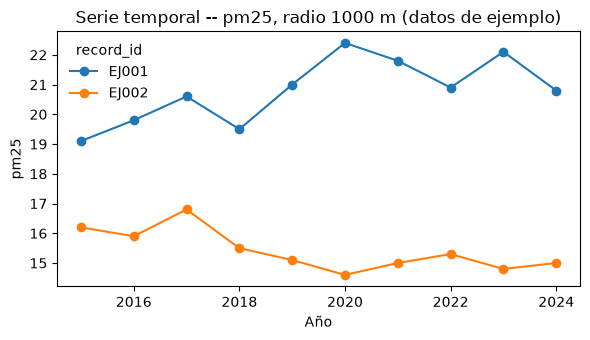

In [5]:
def graficar_serie_temporal(annual_df: pd.DataFrame, indicador: str, radio: int,
                             record_ids: list[str] | None = None):
    """Serie temporal (año vs. valor) de un indicador y radio, un trazo por participante."""
    subset = annual_df[(annual_df["exposome_id"] == indicador) & (annual_df["radius_m"] == radio)]
    if record_ids is not None:
        subset = subset[subset["record_id"].isin(record_ids)]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    for record_id, grupo in subset.sort_values("year").groupby("record_id"):
        ax.plot(grupo["year"], grupo["value"], marker="o", label=record_id)
    ax.set_xlabel("Año")
    ax.set_ylabel(indicador)
    ax.set_title(f"Serie temporal -- {indicador}, radio {radio} m (datos de ejemplo)")
    ax.legend(frameon=False, title="record_id")
    fig.tight_layout()
    return fig, ax


graficar_serie_temporal(example_annual, "pm25", 1000)
plt.show()


La misma función sirve para cualquier indicador y radio presentes en
`point_exposome_annual.csv` real -- basta con cambiar los argumentos
`indicador` y `radio`.


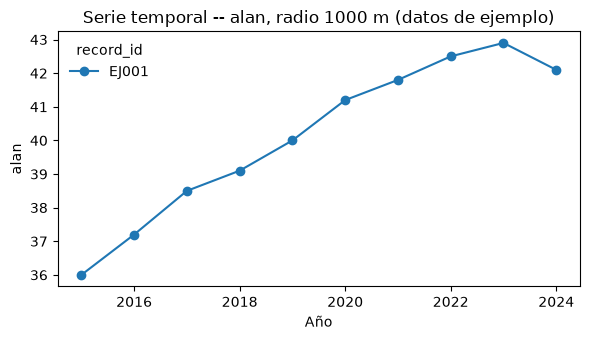

In [6]:
graficar_serie_temporal(example_annual, "alan", 1000)
plt.show()


## 3. Significado del radio de búsqueda

Un indicador de exposoma no corresponde a un valor puntual: corresponde a
un valor definido sobre una región de soporte (el píxel satelital, la celda
de reanálisis, la unidad administrativa). Solicitar a un dato con soporte de
área una respuesta de soporte puntual constituye el *problema de cambio de
soporte* (change-of-support problem); la metodología completa (estimadores,
incertidumbre) puede solicitarse a BrainLat junto con cada entrega.

En términos generales: para un punto `x`, un indicador y un radio `r`, el
valor entregado corresponde al promedio del indicador sobre el disco de
radio `r` alrededor de `x` (`r=0` corresponde a la celda que contiene al
punto: el valor publicado, sin modelo adicional).

| radio | interpretación |
|---|---|
| `0` m | celda o unidad que contiene al participante -- el valor publicado, sin buffer |
| `300` m | estándar de acceso a área verde de la OMS |
| `500` m | distancia caminable (~5-10 min a pie) |
| `1000` m | escala de barrio; resolución mínima para PM2.5 (grilla ~1.1 km) |

**Regla central**: un radio inferior a la resolución de observación real del
indicador no promedia información adicional; devuelve el mismo valor de la
celda contenedora, marcado `sub_observation` en lugar de `ok`. El valor se
entrega de todas formas (para mantener comparabilidad entre indicadores),
pero no debe interpretarse como si describiera variación real a esa escala.


In [7]:
# Ejemplo sobre el DataFrame sintetico: PM2.5 (grilla ~1 km) permanece en
# sub_observation hasta 500m -- el radio no agrega resolucion nueva hasta
# 1000m. ALAN (grilla mas fina) ya resuelve desde 300m.
participant = example_wide.iloc[0]
for indicador in ("pm25", "alan"):
    print(f"--- {indicador} ---")
    for radio in (0, 300, 500, 1000):
        valor = participant[f"{indicador}_r{radio}m"]
        flag = participant[f"{indicador}_r{radio}m_flag"]
        print(f"  r={radio:>4}m  valor={valor:>6}  flag={flag}")


--- pm25 ---
  r=   0m  valor=  21.4  flag=sub_observation
  r= 300m  valor=  21.3  flag=sub_observation
  r= 500m  valor=  21.1  flag=sub_observation
  r=1000m  valor=  20.8  flag=ok
--- alan ---
  r=   0m  valor=  42.1  flag=ok
  r= 300m  valor=  39.8  flag=ok
  r= 500m  valor=  37.2  flag=ok
  r=1000m  valor=  33.0  flag=ok


**Regla práctica**: para un indicador dado, se recomienda utilizar el radio
más pequeño marcado `ok` en la columna `_flag` correspondiente. Un radio
mayor marcado `sub_observation` no aporta información adicional: repite el
valor de la celda.


## 4. Tutorial práctico con pandas

Los ejemplos siguientes se ejecutan sobre `example_wide`. Para trabajar con
datos reales, sustituir por
`pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str, "country_code": str})`.
La especificación explícita de `dtype` es necesaria: sin ella, pandas puede
interpretar `record_id` como valor numérico y truncar identificadores que
comienzan con letras.


### 4.1 Carga e inspección de los datos


In [8]:
# df = pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str, "country_code": str})
df = example_wide.copy()

print(f"{len(df)} participantes, {df.shape[1]} columnas")
print()
print("Columnas de contexto:", sorted(context_columns))
print()
print("Indicadores disponibles:", sorted({RADIUS_COLUMN.match(c).group("indicador")
      for c in df.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")}
      | set(admin_columns)))


3 participantes, 27 columnas

Columnas de contexto: ['country_code', 'geocode_precision', 'out_of_coverage_reason', 'record_id']

Indicadores disponibles: ['alan', 'nse', 'pm25', 'pm25_r1000m_mean_allyears', 'pm25_r1000m_median_allyears', 'pm25_r1000m_n_years', 'walkability']


### 4.2 Filtrado de un indicador por radio, excluyendo `sub_observation`


In [9]:
def valores_confiables(df: pd.DataFrame, indicador: str, radio: int) -> pd.DataFrame:
    valor_col, flag_col = f"{indicador}_r{radio}m", f"{indicador}_r{radio}m_flag"
    subset = df[["record_id", valor_col, flag_col]].dropna(subset=[valor_col])
    return subset[subset[flag_col] == "ok"]

valores_confiables(df, "pm25", 1000)


,record_id,pm25_r1000m,pm25_r1000m_flag
0,EJ001,20.8,ok
1,EJ002,15.0,ok


### 4.3 Comparación de un indicador entre participantes


In [10]:
comparacion = df.set_index("record_id")[["pm25_r1000m", "alan_r1000m", "nse", "walkability"]]
comparacion


,pm25_r1000m,alan_r1000m,nse,walkability
record_id,,,,
EJ001,20.8,33.0,0.62,71.0
EJ002,15.0,15.5,-0.31,58.0
EJ003,NaN,NaN,NaN,NaN


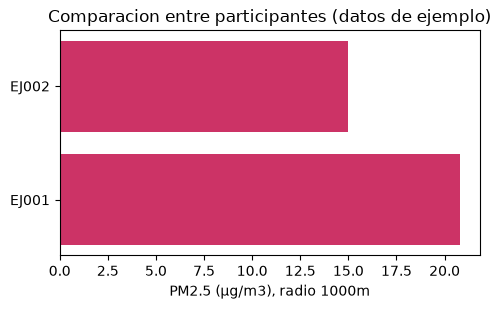

In [11]:
# Comparacion grafica simple (matplotlib estandar, sin estilos adicionales).
visible = comparacion.dropna()
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.barh(visible.index, visible["pm25_r1000m"], color="#CC3366")
ax.set_xlabel("PM2.5 (µg/m3), radio 1000m")
ax.set_title("Comparacion entre participantes (datos de ejemplo)")
fig.tight_layout()
plt.show()


### 4.4 Conversión de formato ancho a largo


In [12]:
radio_cols = [c for c in df.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")]
largo = df.melt(id_vars="record_id", value_vars=radio_cols, var_name="columna", value_name="valor").dropna()
largo[["indicador", "radio_m"]] = largo["columna"].str.extract(r"^(.+)_r(\d+)m$")
largo = largo.drop(columns="columna")
largo.head(10)


,record_id,valor,indicador,radio_m
0,EJ001,21.4,pm25,0
1,EJ002,14.9,pm25,0
3,EJ001,21.3,pm25,300
4,EJ002,14.9,pm25,300
6,EJ001,21.1,pm25,500
7,EJ002,14.9,pm25,500
9,EJ001,20.8,pm25,1000
10,EJ002,15.0,pm25,1000
12,EJ001,42.1,alan,0
13,EJ002,18.6,alan,0


## 5. Preguntas frecuentes

- **¿Por qué un participante no presenta ningún valor?** `geocode_precision
  = unresolved` indica que no fue posible ubicarlo en un punto; nunca se
  asigna una ubicación aproximada o inventada. `out_of_coverage_reason`
  especifica la causa: geocodificación pendiente de mejorar, o ausencia de
  un estudio de GEMMA publicado para esa ciudad.
- **¿`admin_centroid` corresponde al domicilio real del participante?** No.
  Corresponde al punto representativo de su unidad administrativa (comuna,
  distrito, localidad). Es válido para indicadores marcados `ok` a esa
  resolución; no debe interpretarse un buffer de 0-300 m como exposición
  domiciliaria exacta.
- **¿Estos datos representan frecuencia de enfermedad?** No. Describen
  exposición ambiental o social estimada según ubicación; no constituyen un
  desenlace clínico.
- **¿Por qué un indicador no tiene columnas `_median_allyears` /
  `_mean_allyears`?** Solo los
  indicadores que GEMMA publica con serie anual (ver sección 2.1) tienen
  mediana entre años; los indicadores agregados a la unidad administrativa
  (nivel socioeconómico, caminabilidad...) no varían por año en el catálogo
  actual.
- **¿Cómo se solicita una actualización o la incorporación de nuevas
  ciudades?** A través del equipo de BrainLat/GEMMA que entregó el archivo.
